# K04_01 – Polynomielle Regression und Overfitting

Letzter Update am 23. Mai 2026

**Lernziele:**
- Polynomielle Regression mit Graden 2–10 verstehen
- Den Unterschied zwischen **Underfitting** und **Overfitting** visuell und quantitativ erkennen
- **Train/Test-Split**: warum er notwendig ist
- **R²-Kurve**: den Bias-Variance-Tradeoff als Diagramm sehen
- Den "sweet spot" der Modellkomplexität identifizieren

---

### Wichtige Begriffe

| Begriff | Bedeutung |
|---|---|
| **Underfitting** | Modell ist zu einfach → passt weder Training- noch Testdaten gut an |
| **Overfitting** | Modell ist zu komplex → passt Trainingsdaten perfekt, Testdaten schlecht |
| **Train-R²** | Gütemaß auf den Trainingsdaten (In-Sample) |
| **Test-R²** | Gütemaß auf neuen, ungesehenen Daten (Out-of-Sample) – das entscheidende Maß! |
| **Bias-Variance-Tradeoff** | Je komplexer das Modell, desto weniger Bias aber mehr Varianz |

## 1. Bibliotheken importieren

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

print("Alle Bibliotheken erfolgreich geladen ✓")

Alle Bibliotheken erfolgreich geladen ✓


## 2. Datensatz erstellen & Train/Test-Split

**Warum Train/Test-Split?**  
Ohne Split sehen wir nur, wie gut das Modell auf den *Trainingsdaten* funktioniert.
Ein Modell kann Trainingsdaten perfekt auswendig lernen (Overfitting) – aber auf *neuen* Daten
völlig versagen. Deshalb halten wir 30 % der Daten zurück und bewerten das Modell darauf.

```
Gesamtdaten  →  70% Trainingsdaten  +  30% Testdaten
                 (Modell lernt hier)    (Modell wird hier bewertet)
```

In [2]:
# --------------------------------------------------
# Datensatz (fix, reproduzierbar)
# --------------------------------------------------
np.random.seed(42)

n = 40  # etwas mehr Punkte für aussagekräftigeren Test-Split
X = np.linspace(-3, 3, n).reshape(-1, 1)
y = 0.5 * X.ravel()**3 - X.ravel()**2 + X.ravel() + np.random.normal(0, 3, n)

# --------------------------------------------------
# Train/Test-Split: 70% Training, 30% Test
# random_state sorgt für Reproduzierbarkeit
# Hinweis: stratify ist bei Regression nicht verfügbar,
# weil y kontinuierlich ist (keine Klassen). Stratify
# wird nur bei Klassifikation verwendet.
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Fein aufgelöstes Gitter für glatte Regressionskurven
X_plot = np.linspace(-3, 3, 400).reshape(-1, 1)

print(f"Gesamtdaten:     {n} Punkte")
print(f"Trainingsdaten:  {len(X_train)} Punkte (70%)")
print(f"Testdaten:       {len(X_test)} Punkte (30%)")


Gesamtdaten:     40 Punkte
Trainingsdaten:  28 Punkte (70%)
Testdaten:       12 Punkte (30%)


## 3. Polynomielle Regression visualisieren (Grad 2–10)

Jeder Subplot zeigt:
- 🔵 **Blaue Punkte** = Trainingsdaten (zum Lernen)
- 🟠 **Orange Punkte** = Testdaten (zur Bewertung)
- 🔴 **Rote Kurve** = Polynomregression dieses Grades
- **Train-R²** und **Test-R²** im Titel

> ⚠️ **Zu beachten:** Wenn Train-R² ≈ 1, aber Test-R² << 1 → **Overfitting**!

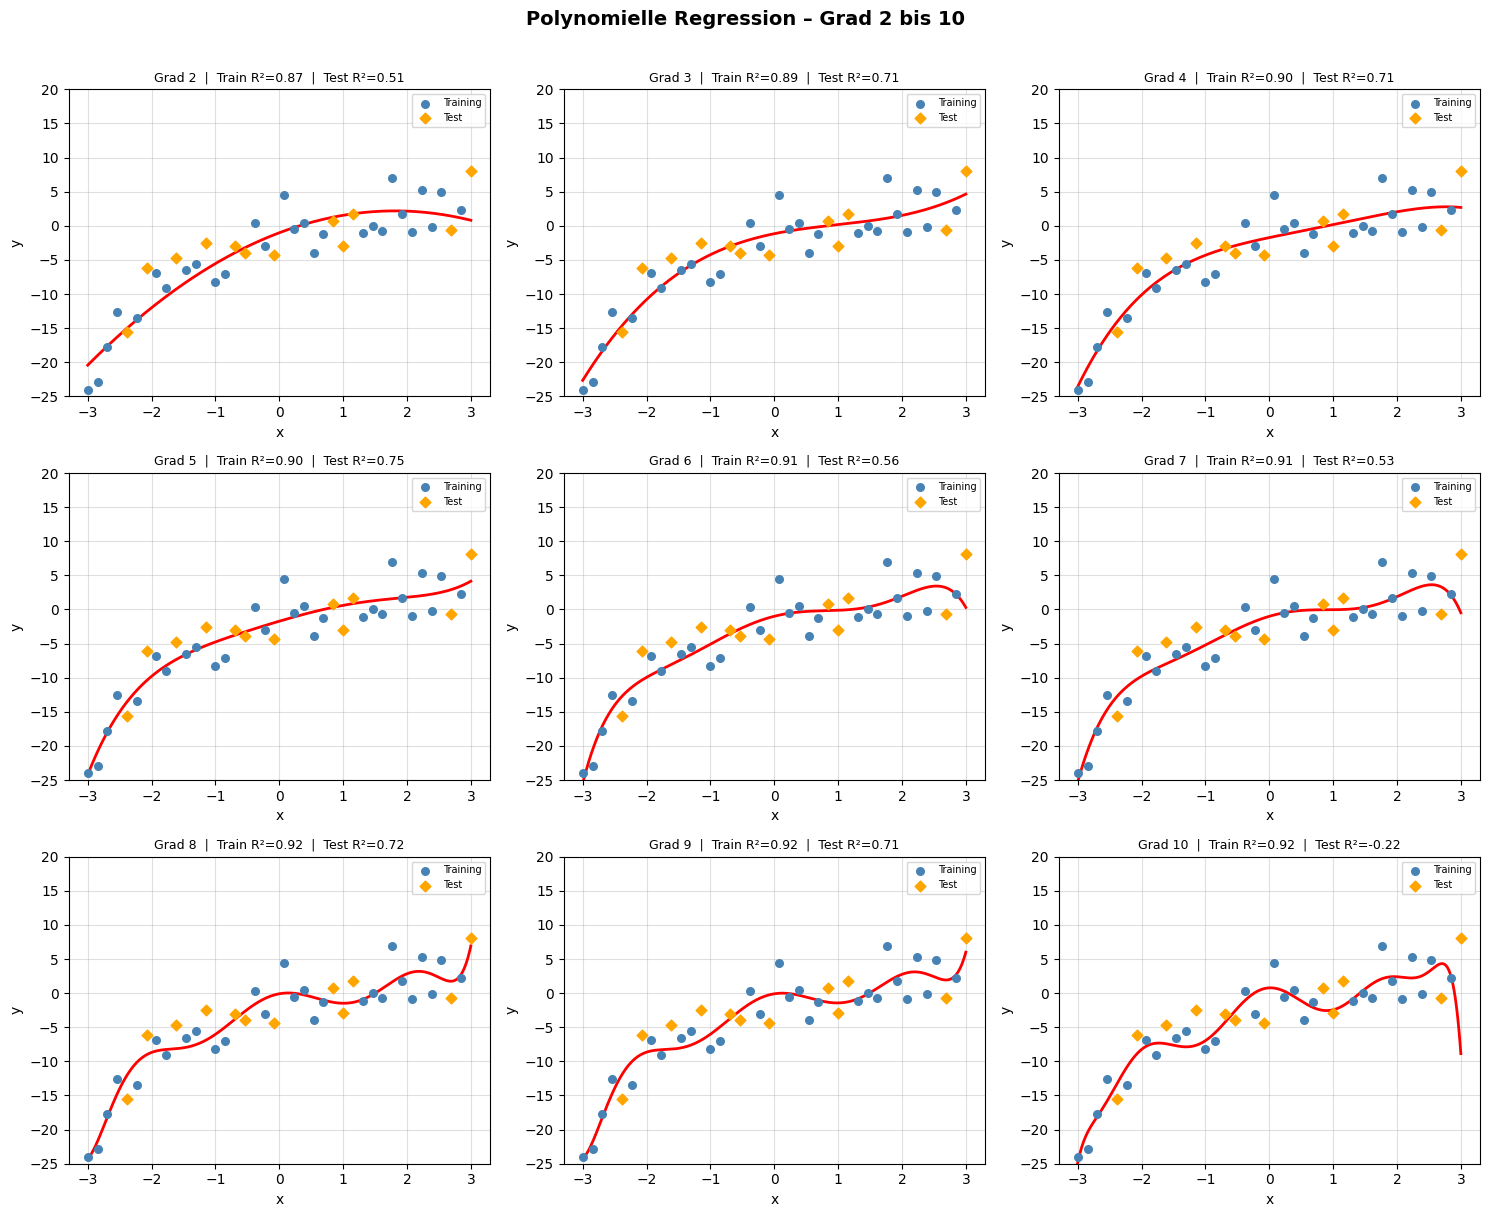

In [3]:
degrees = range(2, 11)  # Grad 2 bis 10

# Speichern der R²-Werte für spätere Analyse
train_r2_scores = []
test_r2_scores  = []

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for ax, deg in zip(axes, degrees):

    # --- Polynomiale Features erzeugen ---
    # include_bias=False: LinearRegression fügt den Achsenabschnitt selbst hinzu
    poly = PolynomialFeatures(degree=deg, include_bias=False)

    # NUR auf Trainingsdaten fitten! (kein Data Leakage)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly  = poly.transform(X_test)          # nur transform, kein fit!
    X_plot_poly  = poly.transform(X_plot)

    # --- Modell trainieren ---
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # --- R²-Scores berechnen ---
    r2_train = model.score(X_train_poly, y_train)
    r2_test  = model.score(X_test_poly,  y_test)

    train_r2_scores.append(r2_train)
    test_r2_scores.append(r2_test)

    # --- Vorhersage für Plot ---
    y_pred = model.predict(X_plot_poly)

    # --- Visualisierung ---
    ax.scatter(X_train, y_train, s=30, color='steelblue', label='Training', zorder=3)
    ax.scatter(X_test,  y_test,  s=30, color='orange',   label='Test',     zorder=3, marker='D')
    ax.plot(X_plot, y_pred, color='red', linewidth=2)

    # Ylim begrenzen damit extreme Overfitting-Kurven nicht alles sprengen
    ax.set_ylim(-25, 20)

    # Titel mit R²-Werten
    ax.set_title(
        f"Grad {deg}  |  Train R²={r2_train:.2f}  |  Test R²={r2_test:.2f}",
        fontsize=9
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=7)

plt.suptitle("Polynomielle Regression – Grad 2 bis 10", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Bias-Variance-Tradeoff: R²-Kurve

Dieser Plot zeigt auf einen Blick den **Bias-Variance-Tradeoff**:

- Train-R² steigt (fast) immer weiter → das Modell lernt die Trainingsdaten auswendig
- Test-R² steigt zunächst, fällt dann wieder → ab einem bestimmten Grad beginnt Overfitting
- Der **Scheitelpunkt des Test-R²** zeigt den optimalen Polynomgrad

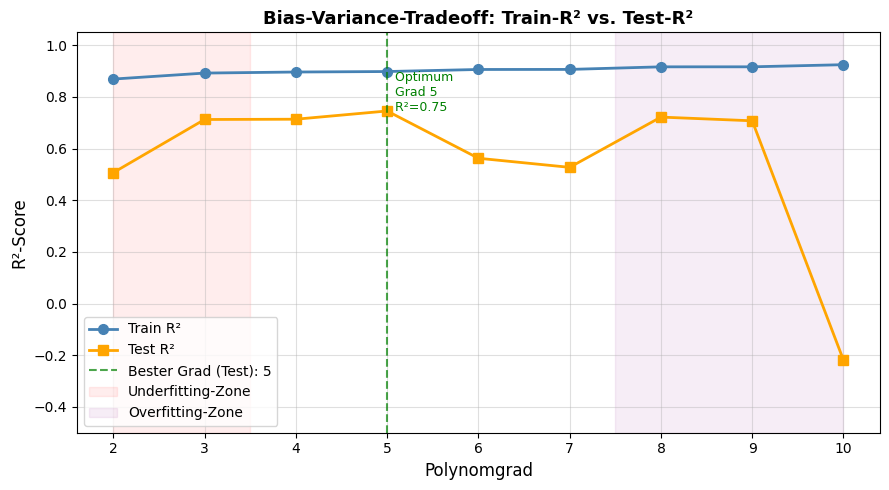


R²-Tabelle:
  Grad   Train-R²    Test-R²
----------------------------
     2      0.869      0.507
     3      0.892      0.713
     4      0.896      0.714
     5      0.898      0.746 ← Optimum
     6      0.906      0.563
     7      0.906      0.527
     8      0.916      0.722
     9      0.917      0.708
    10      0.925     -0.219


In [4]:
degree_list = list(degrees)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(degree_list, train_r2_scores, 'o-', color='steelblue', linewidth=2,
        markersize=7, label='Train R²')
ax.plot(degree_list, test_r2_scores,  's-', color='orange',    linewidth=2,
        markersize=7, label='Test R²')

# Besten Testgrad markieren
best_deg = degree_list[np.argmax(test_r2_scores)]
best_r2  = max(test_r2_scores)
ax.axvline(x=best_deg, color='green', linestyle='--', alpha=0.7,
           label=f'Bester Grad (Test): {best_deg}')
ax.annotate(
    f'  Optimum\n  Grad {best_deg}\n  R²={best_r2:.2f}',
    xy=(best_deg, best_r2),
    fontsize=9, color='green'
)

# Bereiche annotieren
ax.axvspan(2, 3.5,  alpha=0.07, color='red',   label='Underfitting-Zone')
ax.axvspan(7.5, 10, alpha=0.07, color='purple', label='Overfitting-Zone')

ax.set_xlabel("Polynomgrad", fontsize=12)
ax.set_ylabel("R²-Score", fontsize=12)
ax.set_title("Bias-Variance-Tradeoff: Train-R² vs. Test-R²", fontsize=13, fontweight='bold')
ax.set_xticks(degree_list)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_ylim(-0.5, 1.05)

plt.tight_layout()
plt.show()

print("\nR²-Tabelle:")
print(f"{'Grad':>6} {'Train-R²':>10} {'Test-R²':>10}")
print("-" * 28)
for d, tr, te in zip(degree_list, train_r2_scores, test_r2_scores):
    marker = " ← Optimum" if d == best_deg else ""
    print(f"{d:>6} {tr:>10.3f} {te:>10.3f}{marker}")

## 5. Interpretation & Zusammenfassung

### Was wir sehen:

| Grad | Verhalten | Diagnose |
|---|---|---|
| niedrig (2–3) | Train-R² niedrig, Test-R² niedrig | **Underfitting** – Modell zu einfach |
| mittel | Train-R² gut, Test-R² ähnlich gut | ✅ **Guter Kompromiss** |
| hoch (7–10) | Train-R² ≈ 1, Test-R² fällt ab | **Overfitting** – Modell zu komplex |

> **Hinweis:** Welcher Grad konkret der beste ist, hängt von den Daten und dem
> Zufallssplit ab. Der Code oben bestimmt ihn automatisch über `np.argmax(test_r2_scores)`.
> Typischerweise liegt das Optimum bei Grad 4–6, kann aber variieren.

### Die wichtigste Erkenntnis:

> **Ohne Train/Test-Split sieht man Overfitting nicht!**  
> Ein Modell mit Grad 9 kann einen Train-R² von fast 1.0 erreichen – das klingt perfekt.  
> Erst der Test-R² zeigt, dass das Modell auf neuen Daten versagt.

### Warum passiert Overfitting?

```
Grad 9: Das Modell hat 9 Koeffizienten zu lernen, aber nur ~28 Trainingspunkte.
→ Das Modell lernt das Rauschen der Trainingsdaten mit auswendig.
→ Jede kleine Abweichung in den Trainingsdaten wird modelliert.
→ Auf neuen Daten stimmt das Rauschen anders → Modell versagt.
```

### Lösungsansätze für Overfitting:
1. **Weniger Komplexität** (niedrigerer Polynomgrad)
2. **Mehr Trainingsdaten** sammeln
3. **Regularisierung** (Ridge, Lasso)
4. **Cross-Validation** für robustere Modellwahl


## 🔁 Bonus: Interaktiver Polynomgrad-Vergleich

Ändere `grad_a` und `grad_b` und führe die Zelle erneut aus, um zwei Modelle direkt zu vergleichen.

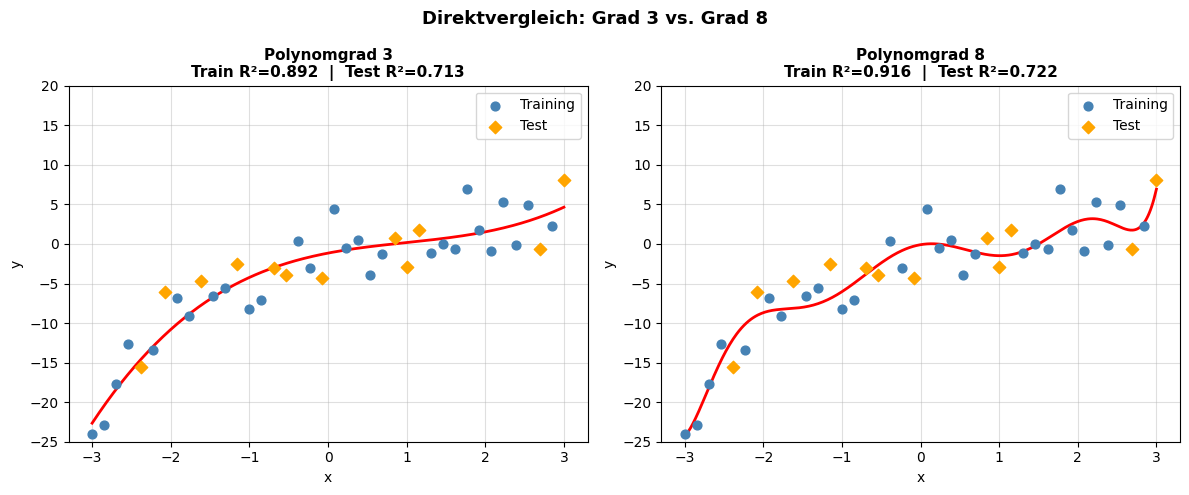

In [5]:
# ← Hier anpassen!
grad_a = 3
grad_b = 8

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, deg in zip(axes, [grad_a, grad_b]):
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly  = poly.transform(X_test)
    X_plot_poly  = poly.transform(X_plot)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    r2_train = model.score(X_train_poly, y_train)
    r2_test  = model.score(X_test_poly,  y_test)

    ax.scatter(X_train, y_train, s=40, color='steelblue', label='Training', zorder=3)
    ax.scatter(X_test,  y_test,  s=40, color='orange',   label='Test',     zorder=3, marker='D')
    ax.plot(X_plot, model.predict(X_plot_poly), color='red', linewidth=2)
    ax.set_ylim(-25, 20)
    ax.set_title(f"Polynomgrad {deg}\nTrain R²={r2_train:.3f}  |  Test R²={r2_test:.3f}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.4)
    ax.legend()

plt.suptitle(f"Direktvergleich: Grad {grad_a} vs. Grad {grad_b}",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Das finale Modell trainieren

Cross-Validation und der R²-Kurven-Vergleich haben uns gezeigt,
bei welchem Polynomgrad das Modell am besten generalisiert.

Jetzt trainieren wir das **finale Modell** mit diesem Grad auf **allen Daten** –
denn für den produktiven Einsatz wollen wir jedes verfügbare Trainingsbeispiel nutzen.

| Schritt | Werkzeug | Zweck |
|---|---|---|
| Besten Grad finden | R²-Kurve über Train/Test | Modellwahl |
| Finales Modell trainieren | `fit(X, y)` auf allen Daten | Einsatzbereit |

> **Merksatz:** Der Train/Test-Split diente der Bewertung –
> das finale Modell nutzt alle Daten.


Bester Polynomgrad laut Test-R²: 5
Test-R² bei bestem Grad:         0.746

Finales Modell (Grad 5) ist einsatzbereit.


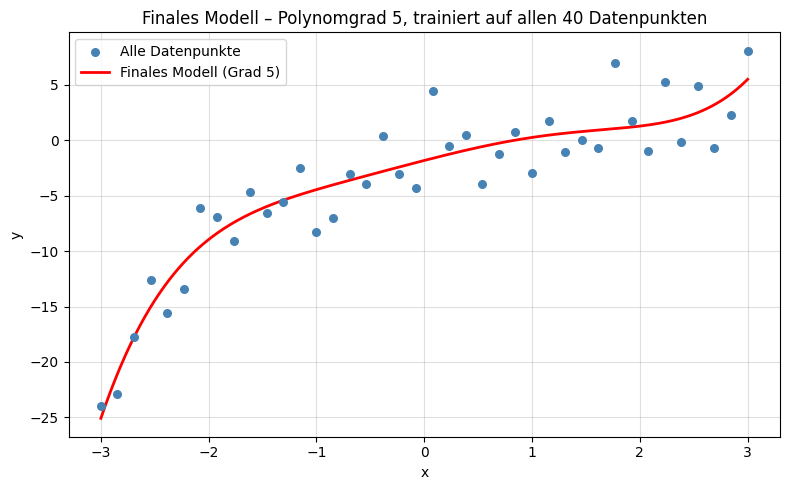

In [6]:
# Besten Polynomgrad aus der R²-Kurve ablesen
bester_grad = list(degrees)[np.argmax(test_r2_scores)]
print(f"Bester Polynomgrad laut Test-R²: {bester_grad}")
print(f"Test-R² bei bestem Grad:         {max(test_r2_scores):.3f}")

# Finales Modell auf ALLEN Daten trainieren
poly_final = PolynomialFeatures(degree=bester_grad, include_bias=False)
X_all_poly = poly_final.fit_transform(X)   # jetzt alle 40 Punkte

final_model = LinearRegression()
final_model.fit(X_all_poly, y)

print(f"\nFinales Modell (Grad {bester_grad}) ist einsatzbereit.")

# Visualisierung des finalen Modells
X_plot_final = poly_final.transform(X_plot)
y_final_pred = final_model.predict(X_plot_final)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='steelblue', s=30, label='Alle Datenpunkte', zorder=3)
plt.plot(X_plot, y_final_pred, color='red', linewidth=2,
         label=f'Finales Modell (Grad {bester_grad})')
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Finales Modell – Polynomgrad {bester_grad}, trainiert auf allen {n} Datenpunkten")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
